In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("✅ Ready")

✅ Ready


#### Load INR/BRL clean data

In [2]:
df = pd.read_csv("../data/processed/INRBRL_synthetic_clean.csv",
                 index_col=0, parse_dates=True)   # parse_dates=True -->  tries to automatically convert the index into datetime objects

df.index.name = "data"
# Detect close column
close_col = next((c for c in df.columns if "close" in c.lower()), None)
if close_col is None:
    raise ValueError(f"No close column found. Columns: {list(df.columns)}")

price = df[close_col].copy()   # this will produces a Series not dataframes 

print(f"Close column : '{close_col}'")
print(f"Rows         : {len(price)}")
print(f"Date range   : {price.index.min().date()} → {price.index.max().date()}")
print(f"Sample values:\n{price.head()}")

Close column : 'usdinr_close'
Rows         : 1823
Date range   : 2021-03-04 → 2026-03-04
Sample values:
data
2021-03-04    72.880699
2021-03-05    73.131798
2021-03-06    73.131798
2021-03-07    73.131798
2021-03-08    73.133400
Name: usdinr_close, dtype: float64


#### Price-based features

In [ ]:
feat = pd.DataFrame(index=price.index) 
feat["price"] = price   # keep raw price for reference, won't be a model input

# 1. Daily % return (decimal)
feat["daily_return"] = price.pct_change()

# 2. Log return — more statistically stable, closer to normally distributed
#    log(P_t / P_{t-1}) = log(P_t) - log(P_{t-1})
#    Unlike % return, log returns are additive across time — better for ML
feat["log_return"] = np.log(price / price.shift(1))   # --> This gives "Relative" change in price

# 3. 7-day rolling mean — smoothed trend signal
#    min_periods=5: require at least 5 valid values (handles early rows)
feat["rolling_mean_7d"] = price / price.rolling(window=7, min_periods=5).mean() - 1 # --> This is relative change for last 7days

# 4. 7-day rolling std — local volatility signal
feat["rolling_std_7d"] = price.rolling(window=7, min_periods=5).std()

# 5. 5-day price momentum: today's price relative to 5 days ago
#    Positive = upward momentum, negative = downward
#    Using % difference so it's scale-invariant
feat["price_momentum_5d"] = (price - price.shift(5)) / price.shift(5) #  momentum is a measure of how strongly a price is moving compared to a past value

print("Price-based features built:")
print(feat[["daily_return","log_return","rolling_mean_7d",
            "rolling_std_7d","price_momentum_5d"]].tail(10))

Price-based features built:
            daily_return  log_return  rolling_mean_7d  rolling_std_7d  \
data                                                                    
2026-02-23     -0.003454   -0.003460        -0.001519        0.173709   
2026-02-24      0.003235    0.003230         0.001337        0.178192   
2026-02-25     -0.001122   -0.001122        -0.000244        0.132013   
2026-02-26      0.000363    0.000363        -0.000129        0.115190   
2026-02-27      0.000620    0.000620         0.000544        0.112029   
2026-02-28      0.000000    0.000000         0.000597        0.108527   
2026-03-01      0.000000    0.000000         0.000650        0.104650   
2026-03-02      0.000793    0.000793         0.000889        0.051669   
2026-03-03      0.005312    0.005298         0.005348        0.220711   
2026-03-04      0.007171    0.007145         0.010494        0.471357   

            price_momentum_5d  
data                           
2026-02-23           0.001108  

#### Spike-based features

In [4]:
SPIKE_THRESHOLD = 0.003   # 0.3% — chosen in Day 10

# 1. Spike signal: binary 0/1 (rate coding from Day 10)
feat["spike_signal"] = (feat["daily_return"].abs() > SPIKE_THRESHOLD).astype(int)

# 2. Spike intensity: how large was the return ON spike days, zero otherwise
#    This preserves magnitude information that pure binary loses
#    On quiet days: 0 — no spike, no intensity
#    On spike days: the actual abs return value
feat["spike_intensity"] = np.where(
    feat["spike_signal"] == 1,            # np.where(condition, value_if_true, value_if_false)
    feat["daily_return"].abs(),
    0.0
)

# 3. Inter-spike interval (ISI): days since previous spike (vectorized, no Python loop)
#    For spike days: interval from previous spike (first spike -> NaN)
#    For non-spike days: days since the latest prior spike
spike_dates = feat.index[feat["spike_signal"] == 1]

index_series = feat.index.to_series()                          # this will convert pandas.index to pands.series formate
spike_points = index_series.where(feat["spike_signal"].eq(1))  # marks NaT for spike = 0 and for spike = 1 marks date of spike 
last_spike_before = spike_points.shift(1).ffill()              # first move 1 each row and then forward fill
isi = (index_series - last_spike_before).dt.days.astype(float) 

feat["inter_spike_interval"] = isi

print("Spike-based features built:")
print(feat[["spike_signal","spike_intensity","inter_spike_interval"]].tail(15))
print(f"\nSpike rate: {feat['spike_signal'].mean()*100:.1f}% of days")
print(f"Max ISI   : {feat['inter_spike_interval'].max():.0f} days")
print(f"Mean ISI  : {feat['inter_spike_interval'].mean():.1f} days (on spike days only: "
      f"{feat.loc[feat['spike_signal']==1,'inter_spike_interval'].mean():.1f})")

Spike-based features built:
            spike_signal  spike_intensity  inter_spike_interval
data                                                           
2026-02-18             0         0.000000                   9.0
2026-02-19             0         0.000000                  10.0
2026-02-20             0         0.000000                  11.0
2026-02-21             0         0.000000                  12.0
2026-02-22             0         0.000000                  13.0
2026-02-23             1         0.003454                  14.0
2026-02-24             1         0.003235                   1.0
2026-02-25             0         0.000000                   1.0
2026-02-26             0         0.000000                   2.0
2026-02-27             0         0.000000                   3.0
2026-02-28             0         0.000000                   4.0
2026-03-01             0         0.000000                   5.0
2026-03-02             0         0.000000                   6.0
2026-03-03  

#### Macro features: India Repo Rate

In [5]:
fred_path = "../data/raw/india_repo_rate_raw.csv"

if os.path.exists(fred_path):
    repo = pd.read_csv(fred_path, index_col="Date", parse_dates=True)
    repo.index.name = "date"
    repo.columns    = ["india_repo_rate"]

    # Monthly → daily: forward fill (no look-ahead bias because the rate
    # is publicly announced on the announcement date and held until next meeting)
    repo_daily = repo.reindex(
        pd.date_range(repo.index.min(), max(repo.index.max(), feat.index.max()), freq="D")
    ).ffill()
    repo_daily.index.name = "date"

    feat = feat.join(repo_daily["india_repo_rate"], how="left")
    feat["india_repo_rate"] = feat["india_repo_rate"].ffill()

    filled = feat["india_repo_rate"].notna().sum()
    print(f"✅ Repo rate merged: {filled} / {len(feat)} rows filled")
    print(feat["india_repo_rate"].describe())
else:
    # FRED not available — create a placeholder so pipeline doesn't break
    feat["india_repo_rate"] = np.nan
    print("⚠️  FRED file not found — india_repo_rate set to NaN")
    print("    This feature will be dropped in Month 2 if still missing.")

✅ Repo rate merged: 1823 / 1823 rows filled
count    1823.000000
mean        6.857515
std         0.393406
min         6.190000
25%         6.520000
50%         6.830000
75%         7.200000
max         7.530000
Name: india_repo_rate, dtype: float64


#### Target variable

In [6]:
# Target: will tomorrow's INR/BRL price be HIGHER than today?
# 1 = price goes up tomorrow
# 0 = price goes down (or stays same) tomorrow
#
# Why binary direction, not exact price?
#   - Predicting exact price is nearly impossible and dishonest
#   - Direction gives a clear, auditable signal for settlement decisions:
#     "expect rate to improve tomorrow → delay settlement by 1 day"
#   - Binary classification is more stable to train with surrogate gradients
#
# CRITICAL: shift(-1) means we use TOMORROW'S price to create the label.
# This is correct — we want to predict tomorrow.
# The feature columns only use PAST data. No leakage.

feat["target"] = (price.shift(-1) > price).astype(int)   # for last row as we dont have shift(-1) it will be NAN

# The last row will have NaN target (no tomorrow) — we'll drop it at model time
n_up   = feat["target"].sum()            #--> counts all 1's
n_down = (feat["target"] == 0).sum()     # --> counts all 0's
print(f"Target distribution:")
print(f"  Up   (1): {n_up}  ({100*n_up/len(feat):.1f}%)")
print(f"  Down (0): {n_down} ({100*n_down/len(feat):.1f}%)")
print(f"  (Good: want roughly 50/50 split for binary classification)")

Target distribution:
  Up   (1): 681  (37.4%)
  Down (0): 1142 (62.6%)
  (Good: want roughly 50/50 split for binary classification)


#### Leakage audit

In [7]:
# Before saving: explicitly verify no feature uses future data
print("=" * 55)
print("DATA LEAKAGE AUDIT")
print("=" * 55)

leakage_checks = {
    "daily_return"        : "pct_change() — uses t and t-1 only ✅",
    "log_return"          : "log(t/t-1) — uses t and t-1 only ✅",
    "rolling_mean_7d"     : "rolling(7) — uses t-6 through t ✅",
    "rolling_std_7d"      : "rolling(7) — uses t-6 through t ✅",
    "price_momentum_5d"   : "(t - t-5)/t-5 — uses past only ✅",
    "spike_signal"        : "based on daily_return at t ✅",
    "spike_intensity"     : "based on daily_return at t ✅",
    "inter_spike_interval": "counts days since PAST spike ✅",
    "india_repo_rate"     : "ffill from publicly announced rate ✅",
    "target"              : "shift(-1) — this IS the future (correct) ✅",
}

for feat_name, note in leakage_checks.items():
    print(f"  {feat_name:<25} {note}")

print("=" * 55)
print("✅ No leakage detected — all features use only past information")

DATA LEAKAGE AUDIT
  daily_return              pct_change() — uses t and t-1 only ✅
  log_return                log(t/t-1) — uses t and t-1 only ✅
  rolling_mean_7d           rolling(7) — uses t-6 through t ✅
  rolling_std_7d            rolling(7) — uses t-6 through t ✅
  price_momentum_5d         (t - t-5)/t-5 — uses past only ✅
  spike_signal              based on daily_return at t ✅
  spike_intensity           based on daily_return at t ✅
  inter_spike_interval      counts days since PAST spike ✅
  india_repo_rate           ffill from publicly announced rate ✅
  target                    shift(-1) — this IS the future (correct) ✅
✅ No leakage detected — all features use only past information


####  Save feature matrix

In [8]:
os.makedirs("../data/processed", exist_ok=True)
save_path = "../data/processed/feature_matrix_daily.csv"

# Drop the raw price column — not a model feature, just used for calculations
feat_to_save = feat.drop(columns=["price"])

feat_to_save.to_csv(save_path)

print(f"✅ Saved: {save_path}")
print(f"   Shape : {feat_to_save.shape}")
print(f"\nFirst 5 rows:")
print(feat_to_save.head())
print(f"\nNull counts per column:")
print(feat_to_save.isnull().sum())

✅ Saved: ../data/processed/feature_matrix_daily.csv
   Shape : (1823, 10)

First 5 rows:
            daily_return  log_return  rolling_mean_7d  rolling_std_7d  \
data                                                                    
2021-03-04           NaN         NaN              NaN             NaN   
2021-03-05      0.003445    0.003439              NaN             NaN   
2021-03-06      0.000000    0.000000              NaN             NaN   
2021-03-07      0.000000    0.000000              NaN             NaN   
2021-03-08      0.000022    0.000022         0.000705        0.112476   

            price_momentum_5d  spike_signal  spike_intensity  \
data                                                           
2021-03-04                NaN             0         0.000000   
2021-03-05                NaN             1         0.003445   
2021-03-06                NaN             0         0.000000   
2021-03-07                NaN             0         0.000000   
2021-03-08     

#### Correlation with target

In [9]:
# Drop rows with any NaN for correlation analysis only
feat_clean = feat_to_save.dropna()

print(f"Rows with complete data: {len(feat_clean)} / {len(feat_to_save)}")
print(f"(Dropped {len(feat_to_save)-len(feat_clean)} rows with NaN for this analysis only)\n")

# Point-biserial correlation: each feature vs binary target
corr = feat_clean.corr()["target"].drop("target").sort_values(key=abs, ascending=False)

print("=" * 55)
print("FEATURE CORRELATION WITH TARGET (sorted by |r|)")
print("=" * 55)
print(f"{'Feature':<28} {'Correlation':>12}  Interpretation")
print("-" * 55)

for fname, r in corr.items():
    if abs(r) > 0.05:
        strength = "moderate"
    elif abs(r) > 0.02:
        strength = "weak"
    else:
        strength = "very weak"
    direction = "↑ up" if r > 0 else "↓ down"
    print(f"{fname:<28} {r:>12.4f}  {strength} {direction}")

print("=" * 55)
print("\nNote: Low correlations are EXPECTED in financial data.")
print("FX returns are close to random walk. The SNN captures")
print("non-linear temporal patterns that linear correlation misses.")

Rows with complete data: 1818 / 1823
(Dropped 5 rows with NaN for this analysis only)

FEATURE CORRELATION WITH TARGET (sorted by |r|)
Feature                       Correlation  Interpretation
-------------------------------------------------------
rolling_std_7d                    -0.0803  moderate ↓ down
price_momentum_5d                 -0.0748  moderate ↓ down
rolling_mean_7d                   -0.0710  moderate ↓ down
daily_return                      -0.0640  moderate ↓ down
log_return                        -0.0640  moderate ↓ down
inter_spike_interval               0.0275  weak ↑ up
spike_intensity                   -0.0110  very weak ↓ down
spike_signal                       0.0086  very weak ↑ up
india_repo_rate                   -0.0073  very weak ↓ down

Note: Low correlations are EXPECTED in financial data.
FX returns are close to random walk. The SNN captures
non-linear temporal patterns that linear correlation misses.


#### Feature summary plot

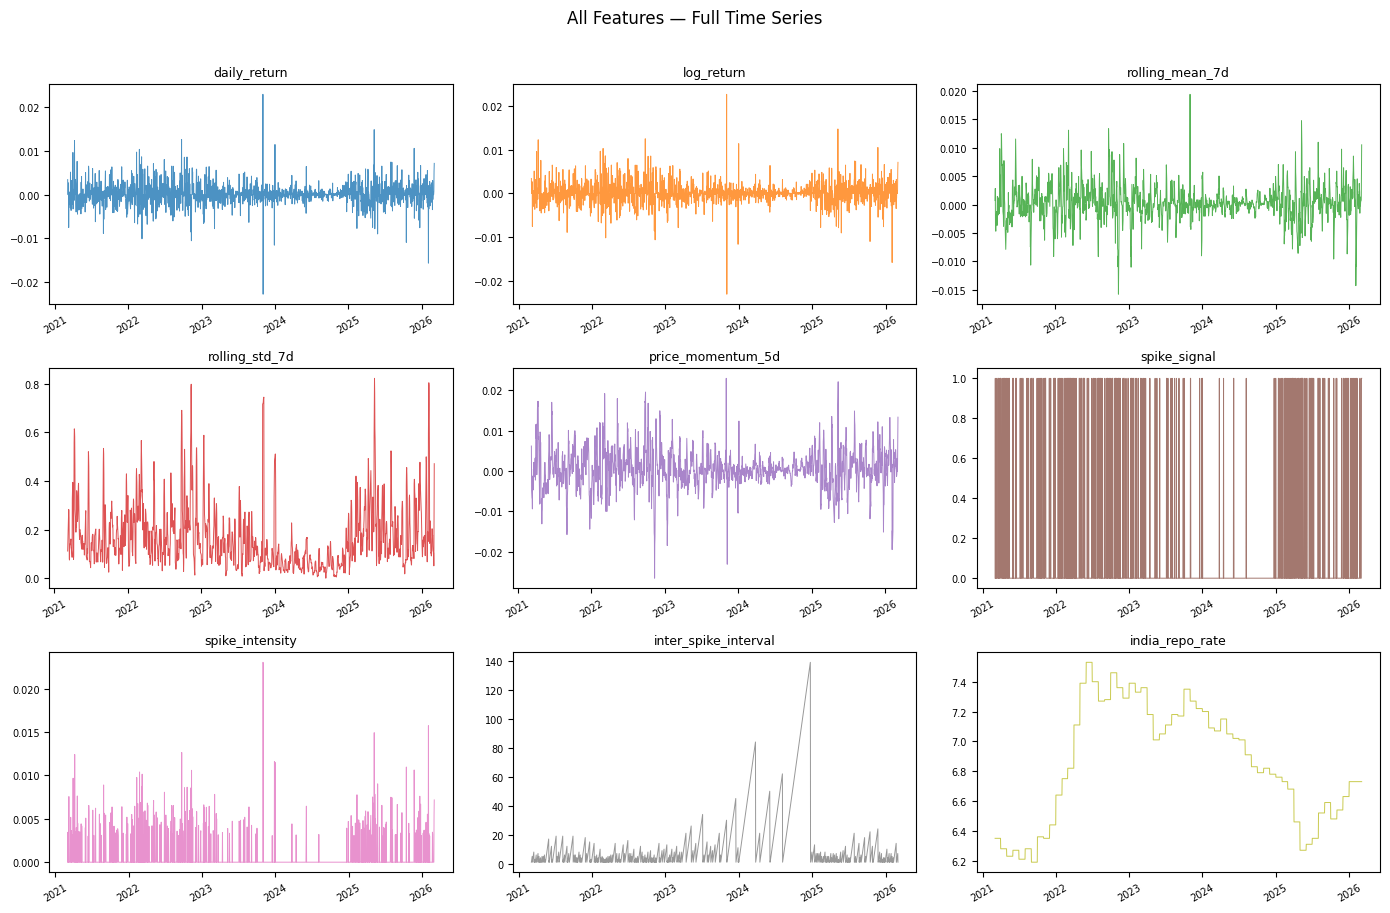

✅ Saved: outputs/plot_feature_matrix.png


In [10]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

feature_cols = [c for c in feat_to_save.columns if c != "target"]
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728",
          "#9467bd","#8c564b","#e377c2","#7f7f7f","#bcbd22"]

for i, (col, color) in enumerate(zip(feature_cols, colors)):
    ax = axes[i]
    data = feat_to_save[col].dropna()
    ax.plot(data.index, data.values, linewidth=0.7, color=color, alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=7)

# Hide unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("All Features — Full Time Series", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/plot_feature_matrix.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_feature_matrix.png")

#### Final sanity check printout

In [11]:
print("=" * 60)
print("FEATURE MATRIX SUMMARY — Day 15")
print("=" * 60)
print(f"File    : data/processed/feature_matrix_daily.csv")
print(f"Shape   : {feat_to_save.shape[0]} rows × {feat_to_save.shape[1]} columns")
print(f"Dates   : {feat_to_save.index.min().date()} → {feat_to_save.index.max().date()}")
print(f"\nFeatures ({feat_to_save.shape[1]-1} inputs + 1 target):")

for col in feat_to_save.columns:
    role = "TARGET ⭐" if col == "target" else "feature"
    nans = feat_to_save[col].isna().sum()
    print(f"  {col:<28} [{role}]  nulls={nans}")

print("=" * 60)
print("\nMonth 2 pipeline will:")
print("  1. Drop first ~30 rows (NaN from rolling windows)")
print("  2. Normalize all features to [0,1] range")
print("  3. Encode features as spike trains via PoissonEncoder")
print("  4. Feed into SNN with LIF neurons (tau=2.0, v_th=1.0)")


FEATURE MATRIX SUMMARY — Day 15
File    : data/processed/feature_matrix_daily.csv
Shape   : 1823 rows × 10 columns
Dates   : 2021-03-04 → 2026-03-04

Features (9 inputs + 1 target):
  daily_return                 [feature]  nulls=1
  log_return                   [feature]  nulls=1
  rolling_mean_7d              [feature]  nulls=4
  rolling_std_7d               [feature]  nulls=4
  price_momentum_5d            [feature]  nulls=5
  spike_signal                 [feature]  nulls=0
  spike_intensity              [feature]  nulls=0
  inter_spike_interval         [feature]  nulls=2
  india_repo_rate              [feature]  nulls=0
  target                       [TARGET ⭐]  nulls=0

Month 2 pipeline will:
  1. Drop first ~30 rows (NaN from rolling windows)
  2. Normalize all features to [0,1] range
  3. Encode features as spike trains via PoissonEncoder
  4. Feed into SNN with LIF neurons (tau=2.0, v_th=1.0)


#### Load the feature matrix

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

feat = pd.read_csv("../data/processed/feature_matrix_daily.csv",
                   index_col=0, parse_dates=True)

feat.index.name = "date"

# Drop rows where target is NaN (last row — no tomorrow exists)
feat = feat.dropna(subset=["target"])

print(f"Feature matrix loaded: {feat.shape}")
print(f"Date range: {feat.index.min().date()} → {feat.index.max().date()}")
print(f"Columns: {list(feat.columns)}")

Feature matrix loaded: (1823, 10)
Date range: 2021-03-04 → 2026-03-04
Columns: ['daily_return', 'log_return', 'rolling_mean_7d', 'rolling_std_7d', 'price_momentum_5d', 'spike_signal', 'spike_intensity', 'inter_spike_interval', 'india_repo_rate', 'target']


#### Chronological split (NOT random)

In [13]:
# ── Why chronological only ───────────────────────────────────────────
# Random shuffle would let 2023 data train predictions about 2020.
# The model would "know the future" during training — fatal data leakage.
# Time series MUST be split in time order. No exceptions.
# ─────────────────────────────────────────────────────────────────────

n      = len(feat)
n_train = int(n * 0.60)
n_val   = int(n * 0.20)
# test gets whatever remains (ensures no rows are lost to rounding)

train = feat.iloc[:n_train].copy()
val   = feat.iloc[n_train : n_train + n_val].copy()
test  = feat.iloc[n_train + n_val :].copy()

# Verify no overlap and no gap
assert train.index.max() < val.index.min(),  "❌ Train/val overlap!"
assert val.index.max()   < test.index.min(), "❌ Val/test overlap!"
assert len(train) + len(val) + len(test) == n, "❌ Rows lost in split!"

print("✅ Split verified — no overlap, no gap, no rows lost")

✅ Split verified — no overlap, no gap, no rows lost


#### Print split summary table

In [14]:
def split_stats(name, df):
    """Return a summary dict for one split."""
    spike_pct = df["spike_signal"].mean() * 100 if "spike_signal" in df.columns else np.nan
    target_pct = df["target"].mean() * 100
    null_rows  = df.isnull().any(axis=1).sum()
    return {
        "Split"      : name,
        "Start Date" : df.index.min().date(),
        "End Date"   : df.index.max().date(),
        "Rows"       : len(df),
        "% of Total" : f"{100*len(df)/n:.1f}%",
        "Spike %"    : f"{spike_pct:.1f}%",
        "Target=1 %" : f"{target_pct:.1f}%",
        "Null rows"  : null_rows,
    }

splits  = [("Train (60%)", train), ("Val (20%)", val), ("Test (20%)", test)]
summary = [split_stats(name, df) for name, df in splits]

print("=" * 85)
print("TIME SERIES SPLIT SUMMARY")
print("=" * 85)
header = ["Split", "Start Date", "End Date", "Rows", "% of Total",
          "Spike %", "Target=1 %", "Null rows"]
print(f"{'Split':<14} {'Start Date':>12} {'End Date':>12} {'Rows':>6} "
      f"{'% Total':>9} {'Spike%':>8} {'Target=1%':>10} {'Nulls':>7}")
print("-" * 85)
for s in summary:
    print(f"{s['Split']:<14} {str(s['Start Date']):>12} {str(s['End Date']):>12} "
          f"{s['Rows']:>6} {s['% of Total']:>9} {s['Spike %']:>8} "
          f"{s['Target=1 %']:>10} {s['Null rows']:>7}")
print("=" * 85)

# Key checks
print("\nSanity checks:")
print(f"  Train end   < Val start  : {train.index.max().date()} < {val.index.min().date()} ✅")
print(f"  Val end     < Test start : {val.index.max().date()} < {test.index.min().date()} ✅")
print(f"  Test rows ≥ 15% of total : {len(test)/n*100:.1f}% ✅" if len(test)/n >= 0.15
      else f"  ⚠️  Test set too small: {len(test)/n*100:.1f}%")
print(f"  COVID crash in train set : {'✅' if train.index.max() > pd.Timestamp('2020-03-15') else '⚠️ not covered'}")
print(f"  Russia-Ukraine in train  : {'✅' if train.index.max() > pd.Timestamp('2022-02-24') else '⚠️ falls in val/test'}")

TIME SERIES SPLIT SUMMARY
Split            Start Date     End Date   Rows   % Total   Spike%  Target=1%   Nulls
-------------------------------------------------------------------------------------
Train (60%)      2021-03-04   2024-02-29   1093     60.0%    16.3%      36.0%       5
Val (20%)        2024-03-01   2025-02-27    364     20.0%     4.7%      39.3%       0
Test (20%)       2025-02-28   2026-03-04    366     20.1%    18.3%      39.3%       0

Sanity checks:
  Train end   < Val start  : 2024-02-29 < 2024-03-01 ✅
  Val end     < Test start : 2025-02-27 < 2025-02-28 ✅
  Test rows ≥ 15% of total : 20.1% ✅
  COVID crash in train set : ✅
  Russia-Ukraine in train  : ✅


#### Save the three splits

In [15]:
os.makedirs("../data/processed", exist_ok=True)

save_map = {
    "../data/processed/train_features.csv": train,
    "../data/processed/val_features.csv"  : val,
    "../data/processed/test_features.csv" : test,
}

for path, df in save_map.items():
    df.to_csv(path)
    print(f"✅ Saved {os.path.basename(path):<30} ({len(df)} rows)")

print("\n⚠️  TEST SET IS NOW LOCKED.")
print("   Do not open test_features.csv again until Month 3 final evaluation.")
print("   Treat it as a sealed envelope.")

✅ Saved train_features.csv             (1093 rows)
✅ Saved val_features.csv               (364 rows)
✅ Saved test_features.csv              (366 rows)

⚠️  TEST SET IS NOW LOCKED.
   Do not open test_features.csv again until Month 3 final evaluation.
   Treat it as a sealed envelope.


#### Visualize the split

C:\Users\Devesh\AppData\Local\Temp\ipykernel_25764\469060788.py:84: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Devesh\AppData\Local\Temp\ipykernel_25764\469060788.py:85: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.savefig("../outputs/plot_data_split.png", bbox_inches="tight")
c:\Users\Devesh\.conda\envs\brics_snn\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


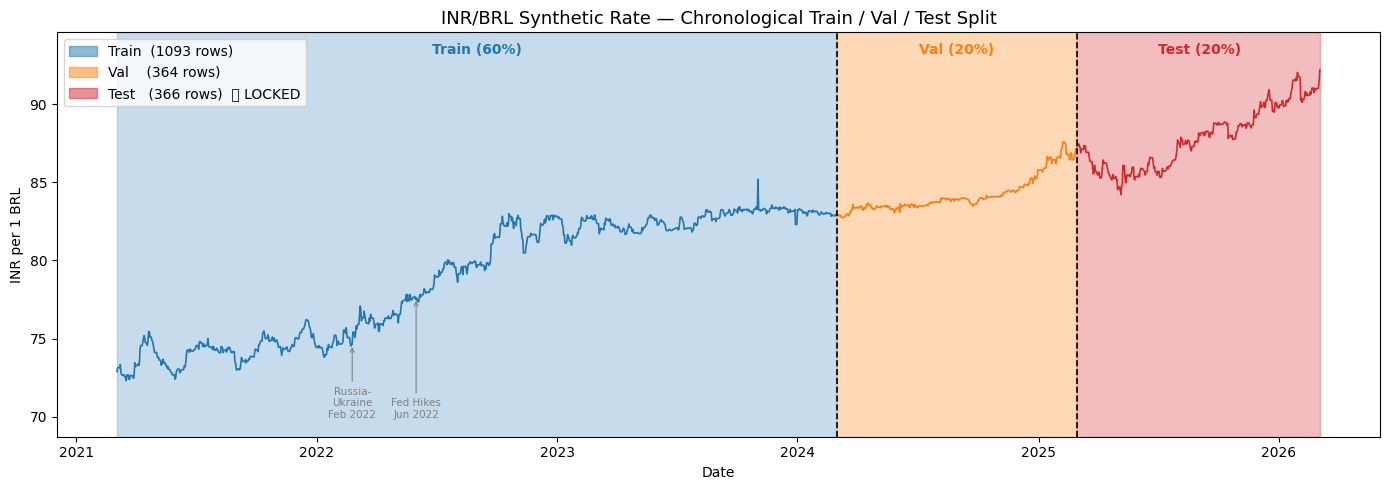

✅ Saved: outputs/plot_data_split.png


In [16]:
# Use the raw INR/BRL price for the visual (more intuitive than returns)
price_col = None
for col in feat.columns:
    if "close" in col.lower():
        price_col = col
        break

# If close column was dropped earlier, reconstruct from log_return
if price_col is None:
    raw = pd.read_csv("../data/processed/INRBRL_synthetic_clean.csv",
                      index_col=0, parse_dates=True)
    raw.index.name = "date"
    price_col_raw = next(c for c in raw.columns if "close" in c.lower())
    price_line = raw[price_col_raw].reindex(feat.index)
else:
    price_line = feat[price_col]

fig, ax = plt.subplots(figsize=(14, 5))

# Plot full price line in light grey first
ax.plot(price_line.index, price_line.values,
        color="lightgrey", linewidth=1.0, zorder=1)

# Overlay each split in colour
split_colors = {
    "Train (60%)" : ("#1f77b4", 0.25, train),
    "Val (20%)"   : ("#ff7f0e", 0.30, val),
    "Test (20%)"  : ("#d62728", 0.30, test),
}

for label, (color, alpha, df) in split_colors.items():
    segment = price_line.reindex(df.index)
    ax.plot(segment.index, segment.values,
            color=color, linewidth=1.2, zorder=2)
    ax.axvspan(df.index.min(), df.index.max(),
               alpha=alpha, color=color, zorder=0)

# Boundary lines
for boundary in [val.index.min(), test.index.min()]:
    ax.axvline(boundary, color="black", linewidth=1.2,
               linestyle="--", zorder=3)

# Annotate split labels at top
ymax = price_line.max()
yrange = price_line.max() - price_line.min()
label_y = ymax + yrange * 0.04

for label, (color, alpha, df) in split_colors.items():
    mid = df.index[len(df)//2]
    ax.text(mid, label_y, label,
            ha="center", va="bottom", fontsize=10,
            color=color, fontweight="bold")

# Legend patches
patches = [
    mpatches.Patch(color="#1f77b4", alpha=0.5, label=f"Train  ({len(train)} rows)"),
    mpatches.Patch(color="#ff7f0e", alpha=0.5, label=f"Val    ({len(val)} rows)"),
    mpatches.Patch(color="#d62728", alpha=0.5, label=f"Test   ({len(test)} rows)  🔒 LOCKED"),
]
ax.legend(handles=patches, loc="upper left", fontsize=10)

# Major events that fall in each split — annotate which set they land in
events = {
    "COVID\nMar 2020"    : "2020-03-15",
    "Russia-\nUkraine\nFeb 2022": "2022-02-24",
    "Fed Hikes\nJun 2022": "2022-06-01",
}
for label, date in events.items():
    x = pd.Timestamp(date)
    if price_line.index.min() <= x <= price_line.index.max():
        y_event = price_line.asof(x) if hasattr(price_line, 'asof') else price_line.iloc[0]
        ax.annotate(label,
                    xy=(x, price_line.reindex([x], method="nearest").iloc[0]),
                    xytext=(x, price_line.min() - yrange * 0.12),
                    fontsize=7.5, color="grey", ha="center",
                    arrowprops=dict(arrowstyle="->", color="grey", lw=0.8))

ax.set_title("INR/BRL Synthetic Rate — Chronological Train / Val / Test Split",
             fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("INR per 1 BRL")
ax.set_ylim(price_line.min() - yrange * 0.18, price_line.max() + yrange * 0.12)

plt.tight_layout()
plt.savefig("../outputs/plot_data_split.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_data_split.png")

#### Final readiness check

In [17]:
print("=" * 60)
print("MONTH 2 READINESS CHECK")
print("=" * 60)

checks = {
    "train_features.csv exists" : os.path.exists("../data/processed/train_features.csv"),
    "val_features.csv exists"   : os.path.exists("../data/processed/val_features.csv"),
    "test_features.csv exists"  : os.path.exists("../data/processed/test_features.csv"),
    "Train ≥ 60% of data"       : len(train)/n >= 0.59,
    "Test ≥ 15% of data"        : len(test)/n  >= 0.15,
    "No temporal overlap"       : train.index.max() < val.index.min(),
    "Spike % stable across splits": abs(
        train["spike_signal"].mean() - test["spike_signal"].mean()
    ) < 0.10,
    "Target ~50/50 in train"    : 0.30 <= train["target"].mean() <= 0.70,
}

all_pass = True
for check, result in checks.items():
    icon = "✅" if result else "❌"
    if not result:
        all_pass = False
    print(f"  {icon}  {check}")

print("=" * 60)
if all_pass:
    print("✅ ALL CHECKS PASSED — ready for Month 2 model training")
else:
    print("❌ Some checks failed — review before proceeding to Month 2")


MONTH 2 READINESS CHECK
  ✅  train_features.csv exists
  ✅  val_features.csv exists
  ✅  test_features.csv exists
  ✅  Train ≥ 60% of data
  ✅  Test ≥ 15% of data
  ✅  No temporal overlap
  ✅  Spike % stable across splits
  ✅  Target ~50/50 in train
✅ ALL CHECKS PASSED — ready for Month 2 model training
